In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [4]:
from src.misc.metrics import *

result_folder = "results/H100/llama3.2-vision_11b-qwen2.5_14b"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

/Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/src/misc/metrics.py:140: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["end_time"] = pd.to_datetime(df["end_time"])
/Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/src/misc/metrics.py:141: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["start_time"] = pd.to_datetime(df["start_time"])


{'task_completion_rate': 1,
 'task_success_rate': 0.9515151515151515,
 'total_execution_time': 9408.231678,
 'mean_execution_time': 4.751632160606061,
 'total_tasks': 1980,
 'SUCCESS': 1884,
 'DB_QUERY_TOOL_NOT_INITIALIZED': 61,
 'DB_UPDATE_TOOL_NOT_INITIALIZED': 33,
 'OCR_TOOL_ARGS_MISMATCH': 1,
 'DB_QUERY_TOOL_ARGS_MISMATCH': 1}

In [5]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,full_logs,total_time,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 20:25:09.009148,2025-03-31 20:25:27.674024,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",18.6649,6,2103,1839,264,0.0,SUCCESS,18.664876,0 days 00:00:18
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 20:25:27.679766,2025-03-31 20:25:32.158530,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",4.4788,6,2131,1852,279,0.0,SUCCESS,4.478764,0 days 00:00:04
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 20:25:32.164388,2025-03-31 20:25:39.293151,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",7.1288,6,2434,1913,521,0.0,SUCCESS,7.128763,0 days 00:00:07
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 20:25:39.298694,2025-03-31 20:25:45.601331,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",6.3026,6,2352,1922,430,0.0,SUCCESS,6.302637,0 days 00:00:06
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-03-31 20:25:45.606830,2025-03-31 20:25:50.324895,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",4.7181,6,2187,1876,311,0.0,SUCCESS,4.718065,0 days 00:00:04


In [6]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

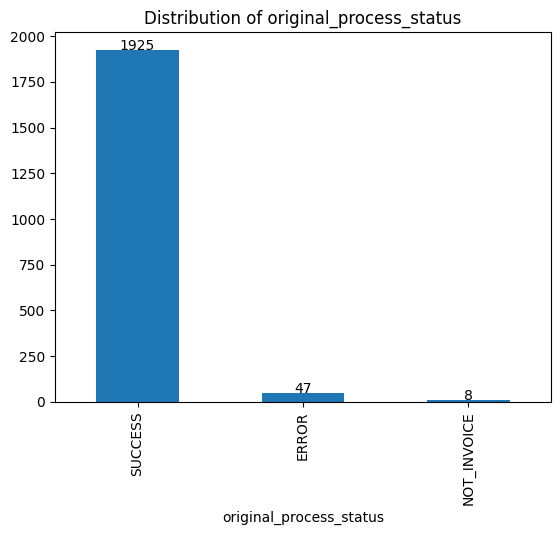

In [7]:
plot_value_distribution(df, "original_process_status")

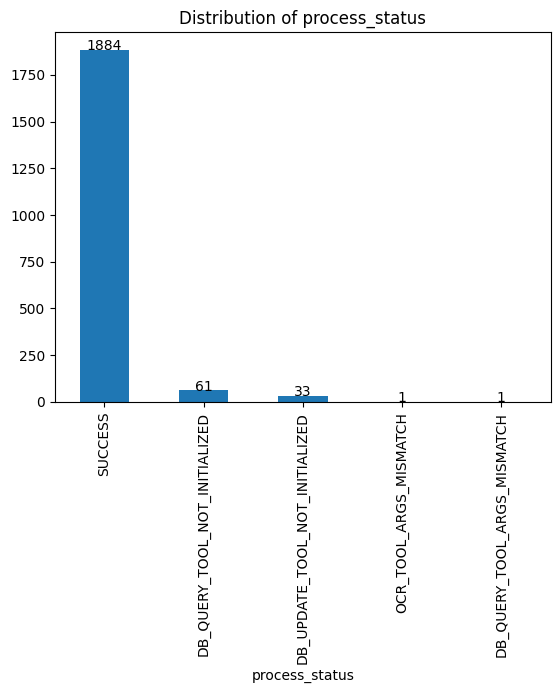

In [8]:
plot_value_distribution(df, "process_status")

In [9]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: SUCCESS
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-03-31 20:25:09.009148
--------------------------------------------------
end_time: 2025-03-31 20:25:27.674024
-----------------------------------------

In [10]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

9

In [11]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-03-31T20:25:09.009148",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-03-31T20:25:23.870092",


In [12]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 538\\nSent by: Robin Levine\\nYou paid $196 to Tanya\\nTransaction Reference Number: EC4F9FE854344D25\\nTransaction Date: 04/23/23\\nInvoice ID: 43925\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 139, \"prompt_tokens\": 90, \"completion_tokens\": 49, \"total_cost\": 0.0}}",
    "timestamp": "2025-03-31T20:25:23.870092",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"43925\", \"bank_name\": \"Bank 538\", \"transaction_id\": \"EC4F9FE854344D25\", \"amount\": \"$196.00\", \"rec

3

In [15]:
df["process_status"].value_counts()

process_status
SUCCESS                           1884
DB_QUERY_TOOL_NOT_INITIALIZED       61
DB_UPDATE_TOOL_NOT_INITIALIZED      33
OCR_TOOL_ARGS_MISMATCH               1
DB_QUERY_TOOL_ARGS_MISMATCH          1
Name: count, dtype: int64

In [16]:
df_filtered = (
    df[df["process_status"] == "OCR_TOOL_ARGS_MISMATCH"].copy().reset_index(drop=True)
)
len(df_filtered)

1

In [17]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: 57E03735DFEA450E9BAA69898BA79B07
--------------------------------------------------
sender_email: JohnRichardson@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 15058
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 15058 , Regards John Richardson
--------------------------------------------------
attachments: transaction_805.jpeg
--------------------------------------------------
process_status: OCR_TOOL_ARGS_MISMATCH
--------------------------------------------------
response: ERROR: The OCR tool encountered an error (FileNotFoundError) and could not process the attachment for Invoice ID 15058. Please check the attachment and ensure it is accessible.
---------------------------------------

In [18]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

4

In [19]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: JohnRichardson@example.com\n            Subject: Payment Confirmation for Invoice ID: 15058\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 15058 , Regards John Richardson\n            Attachment: transaction_805.jpeg\n            \n                ",
    "timestamp": "2025-03-31T21:32:04.863396",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-03-31T21:32:05.3

In [20]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "Error: FileNotFoundError(2, 'No such file or directory')\n Please fix your mistakes.",
    "timestamp": "2025-03-31T21:32:05.399495",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}


1

In [24]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 15058"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [25]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 15058
--------------------------------------------------
bank_name: Bank 465
--------------------------------------------------
transaction_id: D0A2D6D7AA1B4CEE
--------------------------------------------------
amount: 112.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: John Richardson
--------------------------------------------------
reconciliation_state: UNPAID
--------------------------------------------------
email_details: 


In [26]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

61